In [1]:
import wilyapi

import seaborn as sns

import matplotlib.pyplot as plt

In [2]:
FIRST_REVISION = '7e8a6fa   '

In [3]:
api = wilyapi.WilyAPI()

In [4]:
raw_df = api.metric_plot("mi", subdir="feets")

In [5]:
raw_df

,File,feets/__init__.py,feets/core.py,feets/datasets/__init__.py,feets/datasets/base.py,feets/datasets/macho.py,feets/datasets/ogle3.py,feets/datasets/synthetic.py,feets/extractors/__init__.py,feets/extractors/ext_astropy_lomb_scargle.py,feets/extractors/ext_autocor_length.py,...,feets/extractors/light_curve/ext_weighted_mean.py,feets/extractors/light_curve/light_curve_extractor.py,feets/extractors/registry.py,feets/features.py,feets/io.py,feets/libs/__init__.py,feets/libs/bunch.py,feets/libs/doctools.py,feets/preprocess.py,feets/runner.py
Revision,Date,,,,,,,,,,,,,,,,,,,,,
01c7ddb,2024-10-31,95.0787,56.3487,100.0,61.3749,86.0253,77.1249,73.9625,100.0,<NA>,87.0068,...,<NA>,<NA>,55.9822,<NA>,<NA>,100.0,82.7499,82.5769,77.0438,78.7698
03e7f6e,2018-05-24,97.8027,60.4873,100.0,65.0772,100.0,78.6545,79.224,67.7571,<NA>,72.2503,...,<NA>,<NA>,<NA>,<NA>,<NA>,100.0,<NA>,<NA>,76.978,<NA>
04b1141,2024-09-26,97.3884,77.7848,100.0,64.4723,84.0734,78.6658,77.5416,100.0,<NA>,83.8052,...,<NA>,<NA>,<NA>,<NA>,<NA>,100.0,84.6006,<NA>,76.9633,<NA>
0671a91,2018-04-19,97.8027,60.4873,100.0,65.0772,100.0,78.6545,79.224,68.0045,<NA>,72.2503,...,<NA>,<NA>,<NA>,<NA>,<NA>,100.0,<NA>,<NA>,76.978,<NA>
070072a,2018-04-21,97.8027,60.4873,100.0,65.0772,100.0,78.6545,79.224,68.0045,<NA>,72.2503,...,<NA>,<NA>,<NA>,<NA>,<NA>,100.0,<NA>,<NA>,76.978,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f0c894b,2024-08-21,98.3602,56.0048,100.0,65.0772,100.0,78.6545,79.224,67.8802,<NA>,73.8078,...,<NA>,<NA>,<NA>,<NA>,<NA>,100.0,<NA>,<NA>,76.978,<NA>
f8ab77b,2018-04-21,97.8027,60.4873,100.0,65.0772,100.0,78.6545,79.224,68.0045,<NA>,72.2503,...,<NA>,<NA>,<NA>,<NA>,<NA>,100.0,<NA>,<NA>,76.978,<NA>
f91fe99,2024-10-04,95.698,85.8989,100.0,61.3749,86.0253,77.1249,73.9625,100.0,<NA>,87.9467,...,<NA>,<NA>,55.9822,<NA>,<NA>,100.0,84.8294,82.5769,77.0438,90.2306


In [28]:
df = raw_df.sort_index(level=1)

first_revision_date = df.index[df.index.get_level_values(0) == FIRST_REVISION][0][1]
df = df[df.index.get_level_values(1) >= first_revision_date]

# df2 = df2.dropna()
df = df.fillna(0)

/tmp/ipykernel_48967/2562268660.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


In [29]:
def reshape_files_data(df, files):
    dfi = df[files].reset_index().drop(columns=["Revision"])
    dfm = dfi.melt("Date", var_name="File", value_name="Maintainability index")
    return dfm

/tmp/ipykernel_48967/2683870298.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


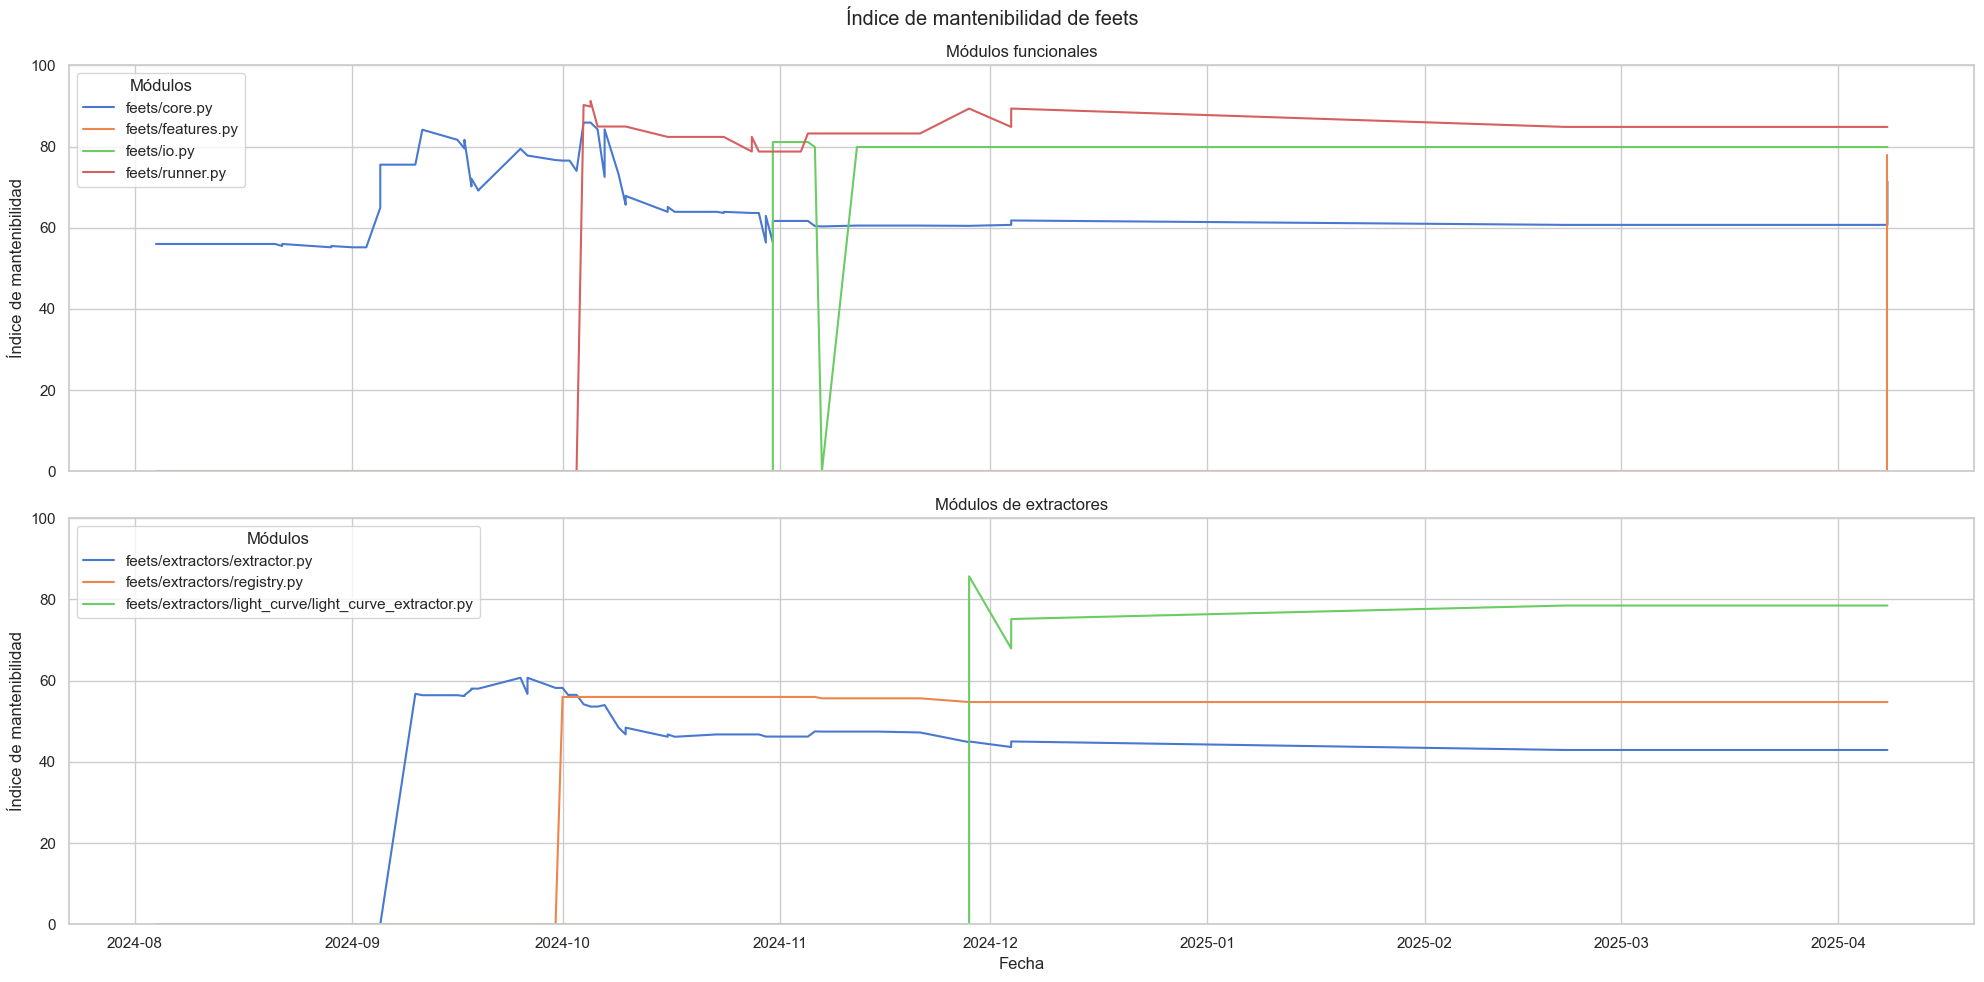

In [ ]:
sns.set(style="whitegrid", palette="muted")

core_files = [
    "feets/core.py",
    "feets/features.py",
    "feets/io.py",
    "feets/runner.py",
]
core_df = reshape_files_data(df, core_files)

extractor_files = [
    "feets/extractors/extractor.py",
    "feets/extractors/registry.py",
    "feets/extractors/light_curve/light_curve_extractor.py",
]
extractor_df = reshape_files_data(df, extractor_files)

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
fig.suptitle("Índice de mantenibilidad de feets")

g = sns.lineplot(
    ax=axes[0],
    x="Date",
    y="Maintainability index",
    hue="File",
    data=core_df,
    estimator=None,
)

axes[0].set_title("Módulos funcionales")
axes[0].set_ylabel("Índice de mantenibilidad")
axes[0].set_xlabel("Fecha")
axes[0].set_ylim(0, 100)
g.legend_.set_title("Módulos")


g = sns.lineplot(
    ax=axes[1],
    x="Date",
    y="Maintainability index",
    hue="File",
    data=extractor_df,
    estimator=None,
)

axes[1].set_title("Módulos de extractores")
axes[1].set_ylabel("Índice de mantenibilidad")
axes[1].set_xlabel("Fecha")
axes[1].set_ylim(0, 100)
g.legend_.set_title("Módulos")

fig.tight_layout()
fig.show()
fig.savefig("feets_MI.pdf", dpi=300)